In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score, cross_val_predict, train_test_split, GridSearchCV
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, log_loss

In [ ]:
import matplotlib.pyplot as plt


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/data for Machine learning training/data label 30 seconds frequency.csv')

In [ ]:
df.head()

,timestamp,devID,soil_mean,rain_mean,temp_mean,humi_mean,geo_mean,hour,label
0,5/2/2025 12:00,101,28.766666,0.0,35.233590,61.564409,14.308251,12,NaN
1,5/2/2025 12:00,101,28.799999,0.0,35.331501,62.408737,15.891333,12,NaN
2,5/2/2025 12:01,101,28.799999,0.0,35.379566,61.602236,14.088287,12,NaN
3,5/2/2025 12:01,101,28.766666,0.0,35.430302,63.564610,15.119175,12,NaN
4,5/2/2025 12:02,101,28.766666,0.0,35.508638,64.492868,14.641307,12,NaN


In [ ]:
df['label'] = df['label'].fillna('normal')

In [ ]:
print(df)

           timestamp  devID  soil_mean  rain_mean  temp_mean  humi_mean  \
0     5/2/2025 12:00    101  28.766666        0.0  35.233590  61.564409   
1     5/2/2025 12:00    101  28.799999        0.0  35.331501  62.408737   
2     5/2/2025 12:01    101  28.799999        0.0  35.379566  61.602236   
3     5/2/2025 12:01    101  28.766666        0.0  35.430302  63.564610   
4     5/2/2025 12:02    101  28.766666        0.0  35.508638  64.492868   
...              ...    ...        ...        ...        ...        ...   
4881  5/4/2025 11:55    101  48.366667        0.0  33.772026  69.169754   
4882  5/4/2025 11:56    101  48.400002        0.0  33.766685  69.380520   
4883  5/4/2025 11:57    101  48.400002        0.0  33.756004  67.130768   
4884  5/4/2025 11:57    101  48.350000        0.0  33.789387  68.244675   
4885  5/4/2025 11:58    101  48.350000        0.0  33.734642  67.111694   

       geo_mean  hour   label  
0     14.308251    12  normal  
1     15.891333    12  normal  
2  

In [ ]:
feature_column=['soil_mean','rain_mean','temp_mean','humi_mean','geo_mean',]
target_column='label'
x=df[feature_column]
y=df[target_column]

In [ ]:
# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)
print(f"\nData split complete")
print(f"Training set has {X_train.shape[0]} samples")
print(f"Testing set has {X_test.shape[0]} samples")
print("\nTraining set label distribution:")
print(y_train.value_counts())


Data split complete
Training set has 3908 samples
Testing set has 978 samples

Training set label distribution:
label
normal      3695
warning      150
critical      63
Name: count, dtype: int64


In [ ]:
import joblib

model=RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

print("Training the model... ⏳")
model.fit(X_train, y_train)
print("Model training complete! ✅")

# Define the path to save the model in Google Drive
model_path = '/content/drive/MyDrive/data for Machine learning training/random_forest_model.joblib'

# Save the trained model
joblib.dump(model, model_path)
print(f"Model saved to {model_path}")

Training the model... ⏳
Model training complete! ✅
Model saved to /content/drive/MyDrive/data for Machine learning training/random_forest_model.joblib


In [ ]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("\n--- Model Performance Metrics ---")
print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1 Score:", round(f1, 3))
print("Classification Report:\n", classification_report(y_test, y_pred, zero_division=0))


--- Model Performance Metrics ---
Accuracy: 0.998
Precision: 0.998
Recall: 0.998
F1 Score: 0.998
Classification Report:
               precision    recall  f1-score   support

    critical       1.00      1.00      1.00        16
      normal       1.00      1.00      1.00       924
     warning       0.95      1.00      0.97        38

    accuracy                           1.00       978
   macro avg       0.98      1.00      0.99       978
weighted avg       1.00      1.00      1.00       978



In [ ]:
# Assuming y_pred_proba has columns corresponding to the order of labels in model.classes_
# You need to know the order of classes in your model to correctly access probabilities

# Get the index of 'warning' and 'critical' classes
warning_index = list(model.classes_).index('warning')
critical_index = list(model.classes_).index('critical')

# Check if the probability of 'warning' or 'critical' is greater than 0.8 for any sample
# This will return a boolean array
is_anomaly = (y_pred_proba[:, warning_index] > 0.8) | (y_pred_proba[:, critical_index] > 0.8)

# If there is at least one sample predicted as anomaly with probability > 0.8, trigger the alert
if is_anomaly.any():
    # Replace with your actual alert triggering mechanism
    print("Alert: Potential landslide detected!")
    # trigger_alert() # Uncomment this line if you have a trigger_alert function defined
else:
    print("No anomaly detected with probability > 0.8")

Alert: Potential landslide detected!


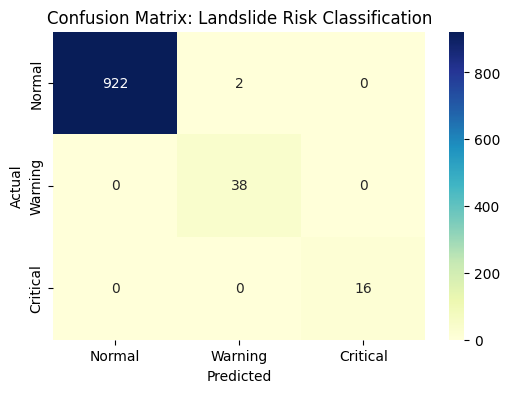

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=['normal','warning','critical'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=["Normal", "Warning", "Critical"],
            yticklabels=["Normal", "Warning", "Critical"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: Landslide Risk Classification")
plt.show()

In [ ]:
import joblib

In [ ]:
loaded_model_path = '/content/drive/MyDrive/data for Machine learning training/random_forest_model.joblib'
loaded_model = joblib.load(loaded_model_path)

print(f"Model loaded from {loaded_model_path}")


Model loaded from /content/drive/MyDrive/data for Machine learning training/random_forest_model.joblib


In [ ]:
new_data_ =pd.read_csv("/content/drive/MyDrive/Landslide project/devID_109_label_data.csv")
new_data_df1 = pd.DataFrame(new_data_)
print("\nNew data for inference:")
display(new_data_df1)


New data for inference:


,soil,rain,temp,humi,geo,iso_risk,lstm_risk,rf,label
0,24.550000,0.0000,32.950001,66.000000,1.865759,0,0,0,NaN
1,24.600000,0.0000,32.700001,70.300003,0.698611,0,0,0,NaN
2,24.600000,0.0000,32.700001,70.300003,0.698611,0,0,0,NaN
3,24.600000,0.0000,32.400002,68.300003,3.730135,0,0,0,NaN
4,24.600000,0.0000,32.400002,68.950001,13.334469,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...
10751,31.849999,0.0000,27.299999,92.150002,0.499649,0,0,0,NaN
10752,31.799999,0.2794,27.400000,91.300003,29.169378,1,0,1,warning
10753,31.799999,0.2794,27.400000,91.300003,10.384488,0,0,1,NaN
10754,31.799999,0.2794,27.400000,91.300003,10.384488,0,0,1,NaN



--- Performance Metrics on New Data (new_data_df1) ---
Accuracy: 0.986
Precision: 0.99
Recall: 0.986
F1 Score: 0.987
Classification Report:
               precision    recall  f1-score   support

    critical       1.00      0.56      0.71        81
      normal       1.00      0.99      0.99     10574
     warning       0.35      0.54      0.43       101

    accuracy                           0.99     10756
   macro avg       0.78      0.70      0.71     10756
weighted avg       0.99      0.99      0.99     10756



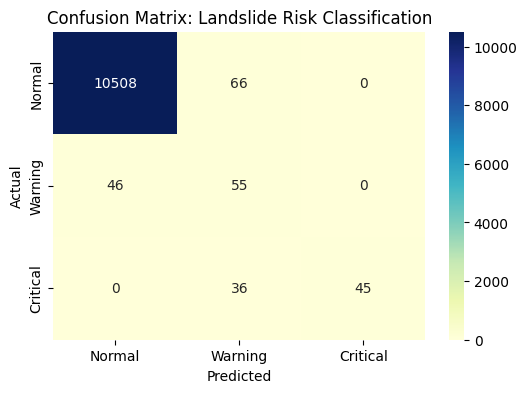

In [ ]:
# Fill missing values in the 'label' column with 'normal'
new_data_df1['label'] = new_data_df1['label'].fillna('normal')

# Use the 'label' column from new_data_df1 as the true labels for evaluation
y_true_new1 = new_data_df1['label']

# Define the feature columns for the new data
feature_column_new = ['soil','rain','temp','humi','geo']

# Rename columns in new_data_df1 to match the training data
new_data_df1 = new_data_df1.rename(columns={
    'soil': 'soil_mean',
    'rain': 'rain_mean',
    'temp': 'temp_mean',
    'humi': 'humi_mean',
    'geo': 'geo_mean'
})

# Update feature_column_new to match the renamed columns
feature_column_new = ['soil_mean','rain_mean','temp_mean','humi_mean','geo_mean']

# Scale the new data (new_data_df1) using the same scaler fitted on the training data
# Make sure the 'scaler' object from the training phase is available
new_data_scaled1 = scaler.transform(new_data_df1[feature_column_new])

# Make predictions on the scaled new data (new_data_df1)
y_pred_new1 = loaded_model.predict(new_data_scaled1)

# Calculate and display performance metrics
accuracy_new1 = accuracy_score(y_true_new1, y_pred_new1)
precision_new1 = precision_score(y_true_new1, y_pred_new1, average='weighted', zero_division=0)
recall_new1 = recall_score(y_true_new1, y_pred_new1, average='weighted', zero_division=0)
f1_new1 = f1_score(y_true_new1, y_pred_new1, average='weighted', zero_division=0)
cm_new1 = confusion_matrix(y_true_new1, y_pred_new1, labels=['normal', 'warning', 'critical'])


print("\n--- Performance Metrics on New Data (new_data_df1) ---")
print("Accuracy:", round(accuracy_new1, 3))
print("Precision:", round(precision_new1, 3))
print("Recall:", round(recall_new1, 3))
print("F1 Score:", round(f1_new1, 3))
print("Classification Report:\n", classification_report(y_true_new1, y_pred_new1, zero_division=0))

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm_new1, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=["Normal", "Warning", "Critical"],
            yticklabels=["Normal", "Warning", "Critical"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: Landslide Risk Classification")
plt.show()